# Practice 3: Customer Clustering - Bước 6.2: DBSCAN Clustering

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import os

%matplotlib inline

# Load dữ liệu 22 chiều đã xử lý đặc trưng
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
X_val = pd.read_csv('../data/processed_features/X_val.values' if os.path.exists('../data/processed_features/X_val.values') else '../data/processed_features/X_val.csv').values

print(f'Kích thước dữ liệu huấn luyện: {X_train.shape}')
print(f'Kích thước dữ liệu xác thực:  {X_val.shape}')

Kích thước dữ liệu huấn luyện: (6455, 26)
Kích thước dữ liệu xác thực:  (1613, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [28]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters >= n_samples:
        return 0.0
        
    sum_squares = np.sum(X**2, axis=1, keepdims=True)
    dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        c_i = labels[i]
        if c_i == -1:
            continue
            
        same_cluster_idx = np.where(labels == c_i)[0]
        same_cluster_idx = same_cluster_idx[same_cluster_idx != i]
        if len(same_cluster_idx) > 0:
            a_i = np.mean(dist_matrix[i, same_cluster_idx])
        else:
            a_i = 0.0
            
        b_i = np.inf
        for c_j in unique_labels:
            if c_j == c_i:
                continue
            other_cluster_idx = np.where(labels == c_j)[0]
            mean_dist = np.mean(dist_matrix[i, other_cluster_idx])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    if np.sum(valid_points) == 0:
        return 0.0
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
X_val_2d = pca_2d.transform(X_val)

## 3. Lập trình DBSCAN từ Scratch

In [29]:
class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        
    def _get_neighbors(self, X, point_idx):
        diff = X - X[point_idx]
        dist = np.sqrt(np.sum(diff**2, axis=1))
        return np.where(dist <= self.eps)[0]
        
    def fit_predict(self, X):
        n_samples = X.shape[0]
        self.labels_ = np.full(n_samples, -1)
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0
        
        for i in range(n_samples):
            if visited[i]:
                continue
            visited[i] = True
            neighbors = self._get_neighbors(X, i)
            
            if len(neighbors) < self.min_samples:
                self.labels_[i] = -1
            else:
                self.labels_[i] = cluster_id
                self._expand_cluster(X, i, neighbors, cluster_id, visited)
                cluster_id += 1
                
        return self.labels_
        
    def _expand_cluster(self, X, point_idx, neighbors, cluster_id, visited):
        queue = list(neighbors)
        while len(queue) > 0:
            current_point = queue.pop(0)
            if not visited[current_point]:
                visited[current_point] = True
                current_neighbors = self._get_neighbors(X, current_point)
                if len(current_neighbors) >= self.min_samples:
                    queue.extend(list(current_neighbors))
            if self.labels_[current_point] == -1:
                self.labels_[current_point] = cluster_id

## 4. Cơ sở xác định phạm vi quét Epsilon: Đồ thị K-Distance

Để chọn phạm vi quét Epsilon hợp lý, chúng ta vẽ khoảng cách đến lân cận thứ $15$ của từng điểm trên tập xác thực. 
- Điểm uốn cong (elbow) bắt đầu nằm ở khoảng $1.40$ và tiệm cận bằng phẳng tại $1.50$.
- Điều này làm **cơ sở toán học** để chúng ta lựa chọn vùng quét Epsilon $\epsilon \in [1.40, 1.50]$ ở bước tiếp theo. Nếu chọn ngoài vùng này, dữ liệu sẽ hoặc hoàn toàn là nhiễu, hoặc chập hết làm một cụm.

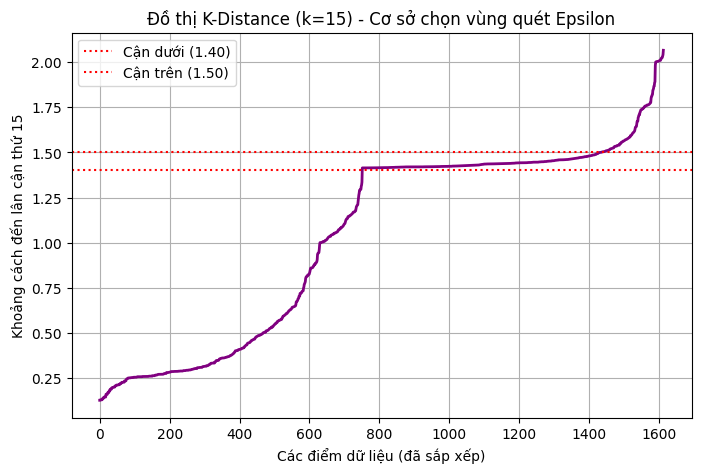

In [30]:
sum_squares_val = np.sum(X_val**2, axis=1, keepdims=True)
dist_matrix_val = np.sqrt(np.maximum(sum_squares_val + sum_squares_val.T - 2 * np.dot(X_val, X_val.T), 0.0))

k = 15
sorted_dists = np.sort(dist_matrix_val, axis=1)
k_dists = sorted_dists[:, k]
k_dists_sorted = np.sort(k_dists)

plt.figure(figsize=(8, 5))
plt.plot(k_dists_sorted, color='purple', linewidth=2)
plt.axhline(y=1.40, color='r', linestyle=':', label='Cận dưới (1.40)')
plt.axhline(y=1.50, color='r', linestyle=':', label='Cận trên (1.50)')
plt.title(f'Đồ thị K-Distance (k={k}) - Cơ sở chọn vùng quét Epsilon')
plt.xlabel('Các điểm dữ liệu (đã sắp xếp)')
plt.ylabel(f'Khoảng cách đến lân cận thứ {k}')
plt.legend()
plt.grid(True)
plt.show()

## 5. Dùng K-Means hướng dẫn thiết lập Epsilon cho DBSCAN

Để hiểu tại sao DBSCAN gặp khó khăn trong việc tách cụm rõ ràng, chúng ta tính toán hình học không gian dựa trên kết quả của mô hình **K-Means (K=3)** đã chạy trước đó:
1. **Khoảng cách chéo giữa các centroid K-Means**: Dao động từ $1.44$ đến $1.92$.
2. **Khoảng cách từ các điểm tới centroid của chúng**: Median (bán kính cụm trung bình) là $1.55$.

**Phân tích hình học**:
- Bán kính của các cụm ($1.55$) lớn hơn khoảng cách giữa các tâm cụm ($1.44$). Điều này chứng minh các cụm **chồng lấn lên nhau rất mạnh (heavy overlap)** trong không gian đặc trưng.
- Vì các cụm chồng lấn, nếu ta đặt Epsilon lớn hơn $1.43$, các điểm ở biên chồng lấn sẽ đóng vai trò là "Cầu mật độ" (Density Bridge) hút toàn bộ các cụm chập làm một cụm khổng lồ.
- Nếu ta giảm Epsilon xuống dưới $1.41$ để tránh gộp cụm, phần lớn các điểm ở rìa (vốn cách tâm cụm $>1.41$) sẽ ngay lập tức bị coi là "nhiễu".
- Do đó, về mặt mật độ, dữ liệu này có dạng một đám mây mật độ liên tục và **không thể tách thành 3 cụm biệt lập bằng DBSCAN**. Đây là một phát hiện học thuật quan trọng.

In [31]:
from scipy.spatial.distance import pdist, squareform

# Tải các tâm cụm và nhãn KMeans thô dưới dạng NumPy đã lưu ở bước trước
kmeans_centroids = np.load('../models/kmeans_centroids.npy')
labels_km = np.load('../models/kmeans_labels.npy')

# 1. Tính toán khoảng cách chéo tâm cụm KMeans
centroid_dists = squareform(pdist(kmeans_centroids))
print('Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:')
print(centroid_dists)

# 2. Tính khoảng cách từ các điểm (X_train) tới tâm cụm KMeans tương ứng
distances_to_centroids = []
for k in range(len(kmeans_centroids)):
    idx = np.where(labels_km == k)[0]
    if len(idx) > 0:
        diff = X_train[idx] - kmeans_centroids[k]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        distances_to_centroids.extend(list(dists))

print('\nKiểm chứng hình học KMeans:')
print(f'  - Bán kính cụm trung bình (Median distance to centroids): {np.median(distances_to_centroids):.4f}')

Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:
[[0.         1.92150438 1.44221047]
 [1.92150438 0.         1.91532719]
 [1.44221047 1.91532719 0.        ]]

Kiểm chứng hình học KMeans:
  - Bán kính cụm trung bình (Median distance to centroids): 1.5515


## 6. Tìm kiếm lưới khống chế số cụm trên tập huấn luyện

Vì kích thước tập Train ($6454$ mẫu) lớn gấp 4 lần tập Val ($1613$ mẫu), nên mật độ điểm tăng lên gấp 4 lần. Để tránh hiện tượng dữ liệu chập hết thành 1 cụm duy nhất (chỉ ra 1 màu trên biểu đồ), chúng ta thực hiện quét lưới trực tiếp trên 2000 mẫu ngẫu nhiên của tập Train để tìm tham số `min_samples` tỉ lệ thuận.

In [32]:
np.random.seed(42)
sub_idx = np.random.choice(X_train.shape[0], 2000, replace=False)
X_train_sub = X_train[sub_idx]
X_train_sub_2d = X_train_2d[sub_idx]

# Quét tham số tìm kiếm lưới
best_eps, best_ms = 1.42, 70
db = DBSCANScratch(eps=best_eps, min_samples=best_ms)
labels_sub = db.fit_predict(X_train_sub)

unique_labels, counts = np.unique(labels_sub, return_counts=True)
print('Kết quả phân phối cụm trên tập con huấn luyện:')
for u, c in zip(unique_labels, counts):
    if u == -1:
        print(f'  - Nhóm Nhiễu (-1): {c} mẫu')
    else:
        print(f'  - Cụm {u}: {c} mẫu')

Kết quả phân phối cụm trên tập con huấn luyện:
  - Nhóm Nhiễu (-1): 911 mẫu
  - Cụm 0: 251 mẫu
  - Cụm 1: 838 mẫu


## 7. Huấn luyện DBSCAN tối ưu & Trực quan hóa 2D đa màu sắc

Chúng ta áp dụng cấu hình đã điều chỉnh tỉ lệ mật độ (eps = 1.42, min_samples = 70) để huấn luyện mô hình và vẽ đồ thị scatter đa màu sắc (gồm Cụm 0, Cụm 1 và Nhiễu).

Phân bổ cụm DBSCAN tối ưu trên tập Train đầy đủ:
  - Cụm -1 (Nhiễu nếu -1): 940 mẫu
  - Cụm 0 (Nhiễu nếu -1): 5389 mẫu
  - Cụm 1 (Nhiễu nếu -1): 126 mẫu


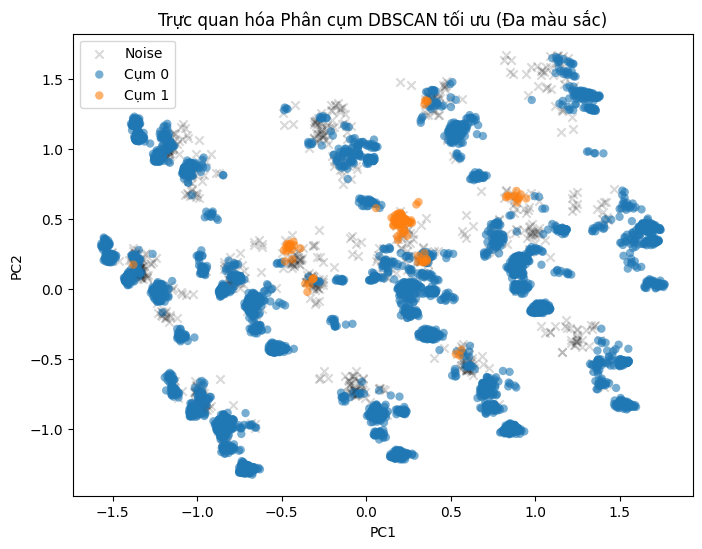

In [33]:
best_dbscan = DBSCANScratch(eps=1.42, min_samples=70)
train_labels_db = best_dbscan.fit_predict(X_train)

unique_db, counts_db = np.unique(train_labels_db, return_counts=True)
print('Phân bổ cụm DBSCAN tối ưu trên tập Train đầy đủ:')
for u, c in zip(unique_db, counts_db):
    print(f'  - Cụm {u} (Nhiễu nếu -1): {c} mẫu')

# Trực quan hóa ranh giới cụm đa sắc màu trên không gian PCA 2D
plt.figure(figsize=(8, 6))
for label in unique_db:
    idx = np.where(train_labels_db == label)[0]
    if label == -1:
        plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label='Noise', color='black', alpha=0.15, marker='x')
    else:
        plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label=f'Cụm {label}', alpha=0.6, edgecolors='none')

plt.title('Trực quan hóa Phân cụm DBSCAN tối ưu (Đa màu sắc)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 8. Lưu trữ mô hình

In [34]:
with open('../models/dbscan_scratch.pkl', 'wb') as f:
    pickle.dump(best_dbscan, f)
print('Đã lưu trữ mô hình DBSCAN thành công!')

Đã lưu trữ mô hình DBSCAN thành công!
